# BrainScanAI — Pipeline complet avec RadImageNet (ResNet50 médical)

Ce notebook utilise **RadImageNet**, un ResNet50 pré-entraîné sur **1.35 million d'images médicales** (IRM, scanner CT, échographie). C'est le choix le plus pertinent pour notre tâche car les features apprises sont directement adaptées à l'imagerie médicale, contrairement à ImageNet.

**Pipeline** :
1. Téléchargement des poids RadImageNet via HuggingFace Hub
2. Extraction de features (embeddings 2048 dim) sur tout le dataset
3. Clustering exploratoire + pseudo-labels (K-Means, DBSCAN, ARI)
4. Comparaison 3 modèles : faible seul / semi-supervisé / supervisé seul
5. Prédiction sur le pool non étiqueté avec score de confiance

In [1]:
import sys
get_ipython().system(f'{sys.executable} -m pip install torch torchvision huggingface_hub scikit-image scikit-learn numpy pandas matplotlib pillow scipy --quiet')
print("Installation terminée.")

Installation terminée.


In [24]:
import time, copy, hashlib, warnings, zipfile
warnings.filterwarnings("ignore")
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
import torchvision.transforms as transforms
from PIL import Image
from skimage.feature import hog
from huggingface_hub import hf_hub_download
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
from sklearn.cluster import KMeans, DBSCAN
from sklearn.neighbors import NearestNeighbors
from sklearn.metrics import (adjusted_rand_score, silhouette_score,
                             accuracy_score, precision_score,
                             recall_score, f1_score, confusion_matrix)
from sklearn.model_selection import train_test_split

import matplotlib

torch.manual_seed(42)
np.random.seed(42)

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"

In [3]:
ZIP_PATH  = Path("mri_dataset_brain_cancer_oc.zip")
DATA_ROOT = Path("mri_dataset_brain_cancer_oc")

if not DATA_ROOT.exists():
    print("Extraction du zip...")
    with zipfile.ZipFile(ZIP_PATH) as zf:
        zf.extractall(".")
    print("OK.")

records = []
for split_dir, label in [
    (DATA_ROOT / "avec_labels" / "normal", "normal"),
    (DATA_ROOT / "avec_labels" / "cancer", "cancer"),
    (DATA_ROOT / "sans_label", None),
]:
    pool = "avec_labels" if label is not None else "sans_label"
    for fp in sorted(split_dir.glob("*.jpg")):
        records.append({"filepath": str(fp), "pool": pool, "label": label})

df = pd.DataFrame(records)

def md5_of(fp):
    with open(fp, "rb") as f:
        return hashlib.md5(f.read()).hexdigest()

df["md5"] = df["filepath"].apply(md5_of)
dup = df["md5"].value_counts()
dup = dup[dup > 1].index
cross = [h for h, g in df[df["md5"].isin(dup)].groupby("md5") if g["pool"].nunique() > 1]
df["exclude_recommended"] = (df["pool"] == "sans_label") & (df["md5"].isin(cross))

df_strong = df[df["pool"] == "avec_labels"].reset_index(drop=True)
df_weak   = df[(df["pool"] == "sans_label") & (~df["exclude_recommended"])].reset_index(drop=True)

print(f"avec_labels : {len(df_strong)} — {df_strong['label'].value_counts().to_dict()}")
print(f"sans_label  : {len(df_weak)} (après exclusion de {df['exclude_recommended'].sum()} doublons)")

avec_labels : 100 — {'normal': 50, 'cancer': 50}
sans_label  : 1374 (après exclusion de 32 doublons)


In [4]:
import torch
import torchvision.models as models
from huggingface_hub import hf_hub_download

print("Téléchargement des poids RadImageNet ResNet50 depuis HuggingFace...")
model_path = hf_hub_download(
    repo_id="Lab-Rasool/RadImageNet",
    filename="ResNet50.pt"
)
print(f"Poids disponibles -> {model_path}")

# 1. Créer l'architecture ResNet50
rad_full = models.resnet50(weights=None)

# 2. Charger les poids
state_dict = torch.load(model_path, map_location=DEVICE)

# 3. Retirer le préfixe "backbone." s'il existe
new_state = {k.replace("backbone.", ""): v for k, v in state_dict.items()}

# 4. Charger les poids dans le modèle
rad_full.load_state_dict(new_state, strict=False)

# 5. Envoyer le modèle sur le bon périphérique
rad_full.to(DEVICE)

# 6. Mode évaluation
rad_full.eval()

# Informations
n = sum(p.numel() for p in rad_full.parameters())
print(f"Modèle chargé : {n:,} paramètres")
print(f"Dernière couche : {rad_full.fc}")

Téléchargement des poids RadImageNet ResNet50 depuis HuggingFace...


Poids disponibles -> C:\Users\adda-\.cache\huggingface\hub\models--Lab-Rasool--RadImageNet\snapshots\14460ee4c1276f6925611a63aa9a54a05d39eae0\ResNet50.pt
Modèle chargé : 25,557,032 paramètres
Dernière couche : Linear(in_features=2048, out_features=1000, bias=True)


In [5]:
# Encodeur = RadImageNet sans la dernière couche FC -> embeddings 2048 dim
rad_encoder = nn.Sequential(*list(rad_full.children())[:-1]).to(DEVICE)
rad_encoder.eval()
for param in rad_encoder.parameters():
    param.requires_grad = False

print("Encodeur RadImageNet prêt (tous paramètres gelés).")
print("Dimension des embeddings : 2048")

Encodeur RadImageNet prêt (tous paramètres gelés).
Dimension des embeddings : 2048


In [6]:
TRANSFORM = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.Grayscale(num_output_channels=3),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
])

class ImgDatasetRad(Dataset):
    def __init__(self, filepaths):
        self.fps = list(filepaths)
    def __len__(self): return len(self.fps)
    def __getitem__(self, i):
        with Image.open(self.fps[i]) as im:
            return TRANSFORM(im.convert("L"))

class ImgDatasetGray(Dataset):
    def __init__(self, filepaths, size=64):
        self.fps = list(filepaths); self.size = size
    def __len__(self): return len(self.fps)
    def __getitem__(self, i):
        with Image.open(self.fps[i]) as im:
            arr = np.array(im.convert("L").resize((self.size, self.size)), dtype=np.float32) / 255.0
        return torch.from_numpy(arr)[None]

def load_gray_np(fp, size=64):
    with Image.open(fp) as im:
        return np.array(im.convert("L").resize((size, size)), dtype=np.float32) / 255.0

print("Datasets définis.")

Datasets définis.


In [7]:
df_all = pd.concat([df_strong, df_weak], ignore_index=True)
is_strong = (df_all["pool"] == "avec_labels").values
y_true_strong = df_all.loc[is_strong, "label"].values

print(f"Extraction embeddings RadImageNet sur {len(df_all)} images...")
t0 = time.time()

embeds = []
loader = DataLoader(ImgDatasetRad(df_all["filepath"]), batch_size=32, shuffle=False)
with torch.no_grad():
    for i, batch in enumerate(loader):
        feat = rad_encoder(batch.to(DEVICE)).squeeze(-1).squeeze(-1)
        embeds.append(feat.cpu().numpy())
        if (i+1) % 10 == 0:
            print(f"  {min((i+1)*32, len(df_all))}/{len(df_all)} images...")

embeds = np.concatenate(embeds, axis=0)
print(f"Embeddings RadImageNet : {embeds.shape} en {time.time()-t0:.1f}s")

Extraction embeddings RadImageNet sur 1474 images...
  320/1474 images...
  640/1474 images...
  960/1474 images...
  1280/1474 images...
Embeddings RadImageNet : (1474, 2048) en 148.2s


In [8]:
print("Extraction features HOG...")
t0 = time.time()
hog_feats = []
for fp in df_all["filepath"]:
    arr = (load_gray_np(fp) * 255).astype(np.uint8)
    hog_feats.append(hog(arr, orientations=8, pixels_per_cell=(8,8),
                         cells_per_block=(2,2), feature_vector=True))
hog_feats = np.stack(hog_feats)
print(f"HOG : {hog_feats.shape} en {time.time()-t0:.1f}s")

np.save("embeddings_radimagenet.npy", embeds)
np.save("features_hog.npy", hog_feats)
df_all.to_csv("manifest_full_ordered.csv", index=False)
print("Sauvegardé.")

Extraction features HOG...
HOG : (1474, 1568) en 14.8s
Sauvegardé.


In [9]:
X_rad = StandardScaler().fit_transform(embeds)
X_hog = StandardScaler().fit_transform(hog_feats)

pca_rad  = PCA(n_components=2, random_state=42)
pca2_rad = pca_rad.fit_transform(X_rad)
pca2_hog = PCA(n_components=2, random_state=42).fit_transform(X_hog)
print(f"PCA RadImageNet variance expliquée : {pca_rad.explained_variance_ratio_.sum():.1%}")

print("Calcul t-SNE...")
tsne2_rad = TSNE(n_components=2, random_state=42, perplexity=30, init="pca").fit_transform(X_rad)
print("t-SNE terminé.")

PCA RadImageNet variance expliquée : 76.2%
Calcul t-SNE...
t-SNE terminé.


In [10]:
def run_kmeans(Xf, name):
    km  = KMeans(n_clusters=2, random_state=42, n_init=10).fit(Xf)
    ari = adjusted_rand_score(y_true_strong, km.labels_[is_strong])
    sil = silhouette_score(Xf, km.labels_)
    print(f"[{name}] K-Means ARI={ari:.3f}  silhouette={sil:.3f}  {np.bincount(km.labels_)}")
    return km.labels_, ari

def sweep_dbscan(Xf, name):
    nn_ = NearestNeighbors(n_neighbors=10).fit(Xf)
    d, _ = nn_.kneighbors(Xf)
    base = np.percentile(np.sort(d[:,-1]), 90)
    best = None
    for m in [0.75, 1.0, 1.25]:
        db = DBSCAN(eps=base*m, min_samples=10).fit(Xf)
        nc = len(set(db.labels_)) - (1 if -1 in db.labels_ else 0)
        ari = adjusted_rand_score(y_true_strong, db.labels_[is_strong]) if nc >= 2 else None
        print(f"[{name}] DBSCAN x{m} -> {nc} clusters, {(db.labels_==-1).sum()} bruit, ARI={ari}")
        if best is None and nc >= 2: best = db.labels_
    return best

print("=== RadImageNet ===")
km_rad, ari_rad = run_kmeans(X_rad, "RadImageNet")
db_rad = sweep_dbscan(X_rad, "RadImageNet")

print("\n=== HOG ===")
km_hog, ari_hog = run_kmeans(X_hog, "HOG")
db_hog = sweep_dbscan(X_hog, "HOG")

=== RadImageNet ===
[RadImageNet] K-Means ARI=-0.009  silhouette=0.347  [875 599]
[RadImageNet] DBSCAN x0.75 -> 2 clusters, 448 bruit, ARI=0.10739524926088287
[RadImageNet] DBSCAN x1.0 -> 1 clusters, 68 bruit, ARI=None
[RadImageNet] DBSCAN x1.25 -> 1 clusters, 13 bruit, ARI=None

=== HOG ===
[HOG] K-Means ARI=0.186  silhouette=0.083  [696 778]
[HOG] DBSCAN x0.75 -> 3 clusters, 999 bruit, ARI=0.017466928276272796
[HOG] DBSCAN x1.0 -> 1 clusters, 58 bruit, ARI=None
[HOG] DBSCAN x1.25 -> 1 clusters, 5 bruit, ARI=None


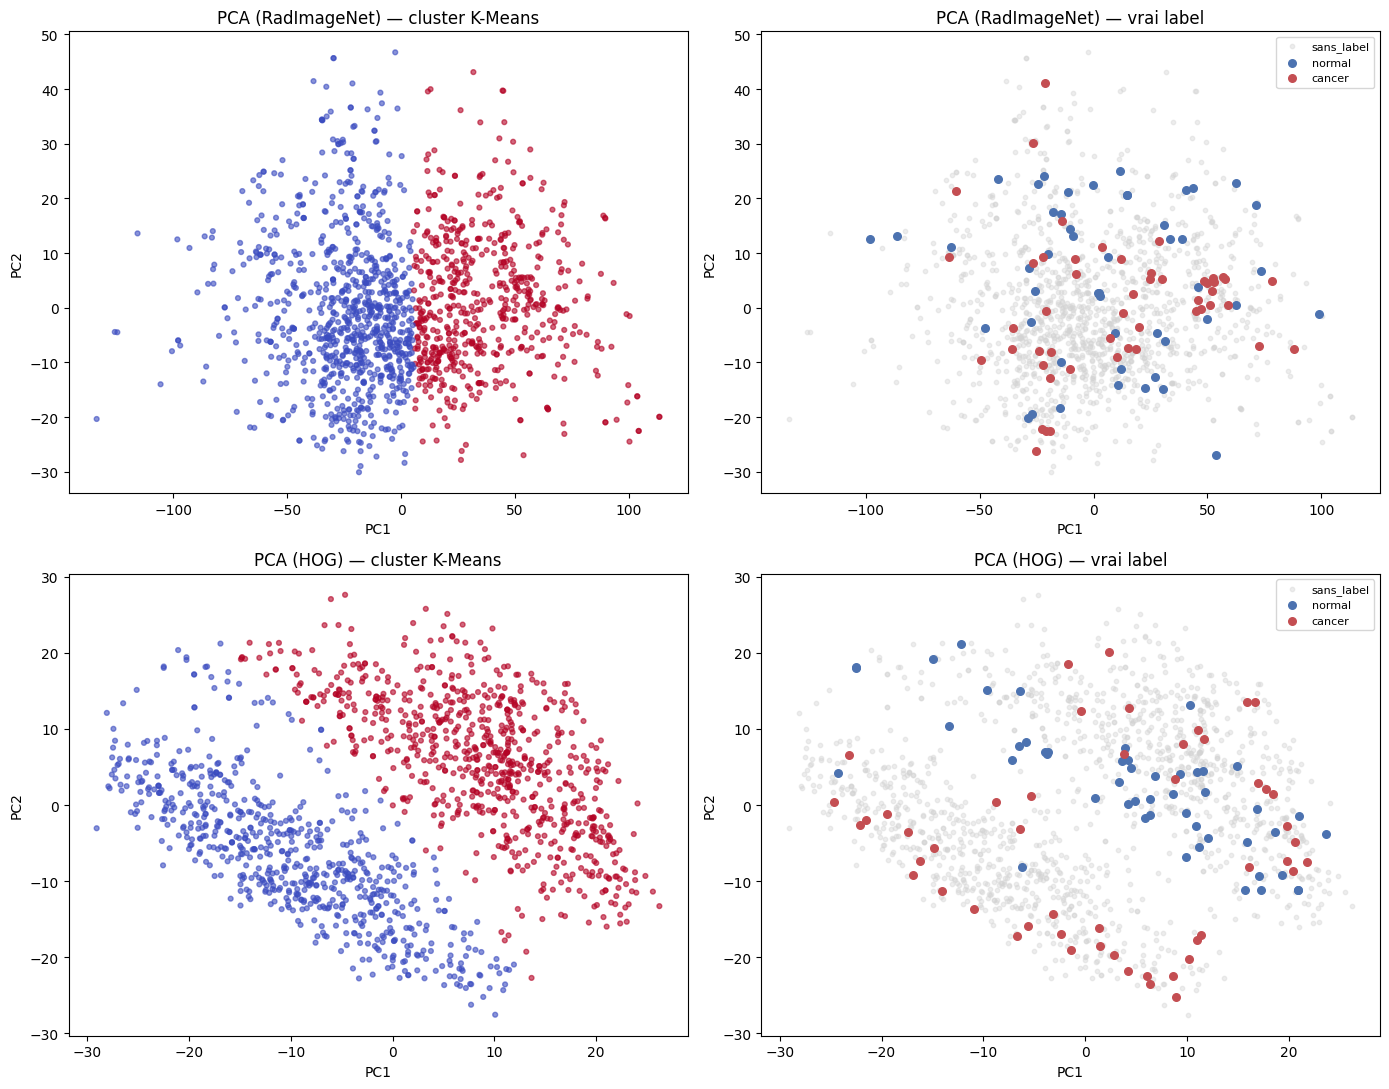

In [11]:
import matplotlib
matplotlib.use("inline")
import matplotlib.pyplot as plt

fig, axes = plt.subplots(2, 2, figsize=(14, 11))
for row, (proj, km, feat) in enumerate([(pca2_rad, km_rad, "RadImageNet"),
                                         (pca2_hog, km_hog, "HOG")]):
    axes[row,0].scatter(proj[:,0], proj[:,1], c=km, cmap="coolwarm", s=12, alpha=0.6)
    axes[row,0].set_title(f"PCA ({feat}) — cluster K-Means")
    axes[row,0].set_xlabel("PC1"); axes[row,0].set_ylabel("PC2")

    ax = axes[row,1]
    ax.scatter(proj[~is_strong,0], proj[~is_strong,1], c="lightgrey", s=10, alpha=0.4, label="sans_label")
    ax.scatter(proj[is_strong & (df_all["label"]=="normal"),0],
               proj[is_strong & (df_all["label"]=="normal"),1], c="#4C72B0", s=30, label="normal")
    ax.scatter(proj[is_strong & (df_all["label"]=="cancer"),0],
               proj[is_strong & (df_all["label"]=="cancer"),1], c="#C44E52", s=30, label="cancer")
    ax.set_title(f"PCA ({feat}) — vrai label")
    ax.set_xlabel("PC1"); ax.set_ylabel("PC2"); ax.legend(fontsize=8)

plt.tight_layout(); plt.savefig("pca_radimagenet.png", dpi=130, bbox_inches="tight"); plt.show()

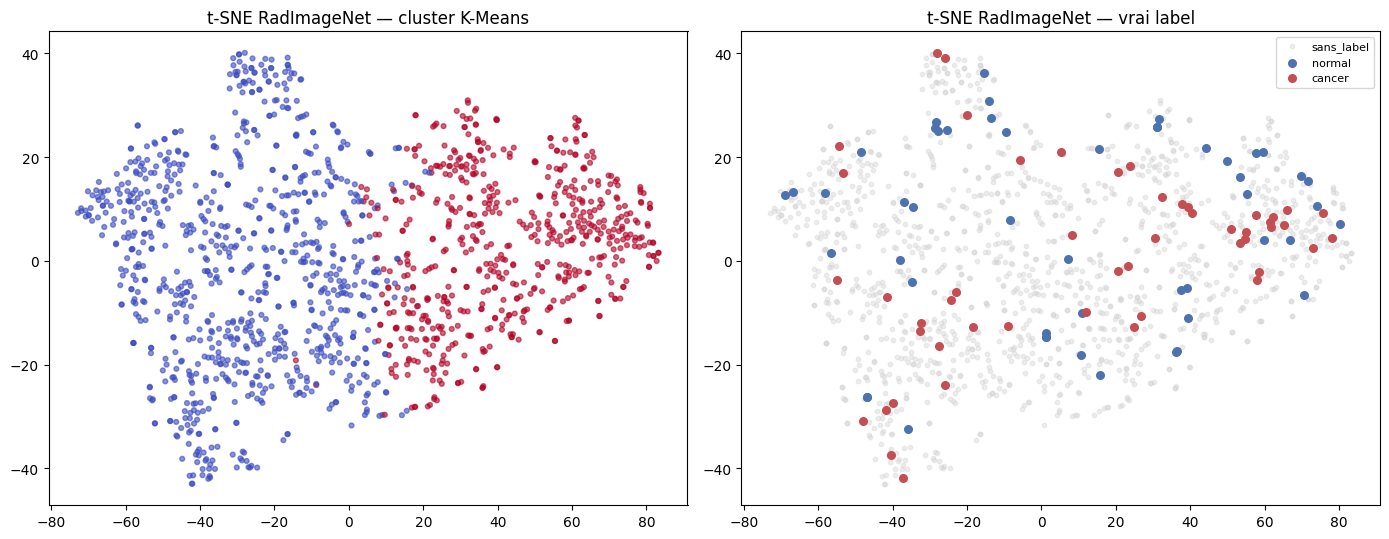

In [12]:
# t-SNE RadImageNet
fig, axes = plt.subplots(1, 2, figsize=(14, 5.5))
axes[0].scatter(tsne2_rad[:,0], tsne2_rad[:,1], c=km_rad, cmap="coolwarm", s=12, alpha=0.6)
axes[0].set_title("t-SNE RadImageNet — cluster K-Means")

ax = axes[1]
ax.scatter(tsne2_rad[~is_strong,0], tsne2_rad[~is_strong,1], c="lightgrey", s=10, alpha=0.4, label="sans_label")
ax.scatter(tsne2_rad[is_strong&(df_all["label"]=="normal"),0], tsne2_rad[is_strong&(df_all["label"]=="normal"),1], c="#4C72B0", s=30, label="normal")
ax.scatter(tsne2_rad[is_strong&(df_all["label"]=="cancer"),0], tsne2_rad[is_strong&(df_all["label"]=="cancer"),1], c="#C44E52", s=30, label="cancer")
ax.set_title("t-SNE RadImageNet — vrai label"); ax.legend(fontsize=8)
plt.tight_layout(); plt.savefig("tsne_radimagenet.png", dpi=130, bbox_inches="tight"); plt.show()

In [13]:
best_labels = km_rad if ari_rad >= ari_hog else km_hog
best_name   = "RadImageNet + K-Means" if ari_rad >= ari_hog else "HOG + K-Means"
best_ari    = max(ari_rad, ari_hog)
print(f"Meilleure combinaison : {best_name} (ARI={best_ari:.3f})")

mapping = {}
for cl in [0,1]:
    mask = is_strong & (best_labels == cl)
    vals, counts = np.unique(df_all.loc[mask, "label"], return_counts=True)
    mapping[cl] = vals[np.argmax(counts)]
    print(f"  Cluster {cl} -> '{mapping[cl]}' {dict(zip(vals,counts))}")

df_all["pseudo_label"] = [mapping[c] for c in best_labels]
df_weak_pseudo = df_all[df_all["pool"] == "sans_label"].copy()
agree = (df_all.loc[is_strong,"pseudo_label"].values == y_true_strong).mean()
print(f"\nAccord pseudo-label / vrai label : {agree:.1%}")
print(df_weak_pseudo["pseudo_label"].value_counts())

Meilleure combinaison : HOG + K-Means (ARI=0.186)
  Cluster 0 -> 'cancer' {'cancer': np.int64(28), 'normal': np.int64(6)}
  Cluster 1 -> 'normal' {'cancer': np.int64(22), 'normal': np.int64(44)}

Accord pseudo-label / vrai label : 72.0%
pseudo_label
normal    712
cancer    662
Name: count, dtype: int64


In [14]:
LABEL2IDX = {"normal":0, "cancer":1}
IDX2LABEL = {0:"normal", 1:"cancer"}

class ClfDataset(Dataset):
    def __init__(self, fps, labels, size=64):
        self.fps = list(fps); self.labels = [LABEL2IDX[l] for l in labels]; self.size = size
    def __len__(self): return len(self.fps)
    def __getitem__(self, i):
        return torch.from_numpy(load_gray_np(self.fps[i], self.size))[None], self.labels[i]

train_strong, test_strong = train_test_split(df_strong, test_size=0.30, random_state=42,
                                              stratify=df_strong["label"])
print(f"train_strong : {len(train_strong)} {train_strong['label'].value_counts().to_dict()}")
print(f"test_strong  : {len(test_strong)} {test_strong['label'].value_counts().to_dict()} (jamais vu)")

weak_loader         = DataLoader(ClfDataset(df_weak_pseudo["filepath"], df_weak_pseudo["pseudo_label"]),
                                 batch_size=32, shuffle=True)
train_strong_loader = DataLoader(ClfDataset(train_strong["filepath"], train_strong["label"]),
                                 batch_size=16, shuffle=True)
test_strong_loader  = DataLoader(ClfDataset(test_strong["filepath"], test_strong["label"]),
                                 batch_size=16, shuffle=False)

train_strong : 70 {'normal': 35, 'cancer': 35}
test_strong  : 30 {'cancer': 15, 'normal': 15} (jamais vu)


In [25]:
import torch
import torch.nn as nn
import torchvision.models as models
import numpy as np
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix)

def build_rad_classifier():
    clf = models.resnet50(weights=None)
    state_dict = torch.load(model_path, map_location=DEVICE)
    state_dict = {
        k.replace("backbone.", ""): v
        for k, v in state_dict.items()
    }
    clf.load_state_dict(state_dict, strict=False)

    for param in clf.parameters():
        param.requires_grad = False

    clf.fc = nn.Linear(clf.fc.in_features, 2)

    for param in clf.fc.parameters():
        param.requires_grad = True

    return clf.to(DEVICE)

def train_model(model, loader, n_epochs, lr, tag):

    opt = torch.optim.Adam(
        [p for p in model.parameters() if p.requires_grad],
        lr=lr
    )

    lossf = nn.CrossEntropyLoss()

    model.train()

    for ep in range(n_epochs):

        tot = 0.0
        correct = 0
        n = 0

        for xb, yb in loader:

            xb = xb.repeat(1, 3, 1, 1).to(DEVICE)
            yb = yb.to(DEVICE)

            opt.zero_grad()

            out = model(xb)

            loss = lossf(out, yb)

            loss.backward()
            opt.step()

            tot += loss.item() * xb.size(0)
            correct += (out.argmax(1) == yb).sum().item()
            n += xb.size(0)

        print(
            f"[{tag}] Epoch {ep+1}/{n_epochs} "
            f"| Loss = {tot/n:.4f} "
            f"| Acc = {correct/n:.3f}"
        )

    return model
def evaluate(model, loader):

    model.eval()

    preds = []
    trues = []

    with torch.no_grad():

        for xb, yb in loader:

            xb = xb.repeat(1, 3, 1, 1).to(DEVICE)

            out = model(xb)

            preds.extend(out.argmax(1).cpu().numpy())
            trues.extend(yb.numpy())

    preds = np.array(preds)
    trues = np.array(trues)

    return {
        "accuracy": accuracy_score(trues, preds),
        "precision_cancer": precision_score(
            trues, preds,
            pos_label=1,
            zero_division=0
        ),
        "recall_cancer": recall_score(
            trues, preds,
            pos_label=1,
            zero_division=0
        ),
        "f1_cancer": f1_score(
            trues, preds,
            pos_label=1,
            zero_division=0
        ),
        "confusion": confusion_matrix(
            trues,
            preds,
            labels=[0, 1]
        )
    }

In [16]:
print("--- Modèle A : RadImageNet fine-tuné sur pseudo-labels ---")
t0 = time.time(); model_A = build_rad_classifier()
model_A = train_model(model_A, weak_loader, n_epochs=3, lr=1e-3, tag="A-faible")
metrics_A = evaluate(model_A, test_strong_loader)
print(f"  {time.time()-t0:.0f}s | acc={metrics_A['accuracy']:.3f} "
      f"recall={metrics_A['recall_cancer']:.3f} f1={metrics_A['f1_cancer']:.3f}")

--- Modèle A : RadImageNet fine-tuné sur pseudo-labels ---
[A-faible] Epoch 1/3 | Loss = 0.8340 | Acc = 0.533
[A-faible] Epoch 2/3 | Loss = 0.7377 | Acc = 0.543
[A-faible] Epoch 3/3 | Loss = 0.6804 | Acc = 0.575
  84s | acc=0.633 recall=0.467 f1=0.560


In [17]:
print("--- Modèle B : semi-supervisé (poids A -> fine-tuning fort) ---")
t0 = time.time(); model_B = copy.deepcopy(model_A)
model_B = train_model(model_B, train_strong_loader, n_epochs=5, lr=5e-4, tag="B-finetune")
metrics_B = evaluate(model_B, test_strong_loader)
print(f"  {time.time()-t0:.0f}s | acc={metrics_B['accuracy']:.3f} "
      f"recall={metrics_B['recall_cancer']:.3f} f1={metrics_B['f1_cancer']:.3f}")

--- Modèle B : semi-supervisé (poids A -> fine-tuning fort) ---
[B-finetune] Epoch 1/5 | Loss = 0.7354 | Acc = 0.600
[B-finetune] Epoch 2/5 | Loss = 0.7360 | Acc = 0.557
[B-finetune] Epoch 3/5 | Loss = 0.6843 | Acc = 0.543
[B-finetune] Epoch 4/5 | Loss = 0.5778 | Acc = 0.714
[B-finetune] Epoch 5/5 | Loss = 0.5859 | Acc = 0.657
  8s | acc=0.733 recall=0.800 f1=0.750


In [18]:
print("--- Modèle C : RadImageNet fine-tuné sur fort seul (baseline) ---")
t0 = time.time(); model_C = build_rad_classifier()
model_C = train_model(model_C, train_strong_loader, n_epochs=8, lr=1e-3, tag="C-fort")
metrics_C = evaluate(model_C, test_strong_loader)
print(f"  {time.time()-t0:.0f}s | acc={metrics_C['accuracy']:.3f} "
      f"recall={metrics_C['recall_cancer']:.3f} f1={metrics_C['f1_cancer']:.3f}")

--- Modèle C : RadImageNet fine-tuné sur fort seul (baseline) ---
[C-fort] Epoch 1/8 | Loss = 1.3165 | Acc = 0.471
[C-fort] Epoch 2/8 | Loss = 0.7539 | Acc = 0.571
[C-fort] Epoch 3/8 | Loss = 0.7802 | Acc = 0.500
[C-fort] Epoch 4/8 | Loss = 0.6979 | Acc = 0.557
[C-fort] Epoch 5/8 | Loss = 0.5976 | Acc = 0.700
[C-fort] Epoch 6/8 | Loss = 0.6756 | Acc = 0.614
[C-fort] Epoch 7/8 | Loss = 0.5922 | Acc = 0.671
[C-fort] Epoch 8/8 | Loss = 0.6880 | Acc = 0.600
  13s | acc=0.500 recall=1.000 f1=0.667


In [19]:
results_table = pd.DataFrame({
    "Modele"             : ["A faible seul", "B semi-supervise", "C fort seul (baseline)"],
    "Accuracy"           : [metrics_A["accuracy"],         metrics_B["accuracy"],         metrics_C["accuracy"]],
    "Precision cancer"   : [metrics_A["precision_cancer"], metrics_B["precision_cancer"], metrics_C["precision_cancer"]],
    "Rappel cancer etoile": [metrics_A["recall_cancer"],   metrics_B["recall_cancer"],    metrics_C["recall_cancer"]],
    "F1 cancer"          : [metrics_A["f1_cancer"],        metrics_B["f1_cancer"],        metrics_C["f1_cancer"]],
}).round(3)
print(results_table.to_string(index=False))

                Modele  Accuracy  Precision cancer  Rappel cancer etoile  F1 cancer
         A faible seul     0.633             0.700                 0.467      0.560
      B semi-supervise     0.733             0.706                 0.800      0.750
C fort seul (baseline)     0.500             0.500                 1.000      0.667


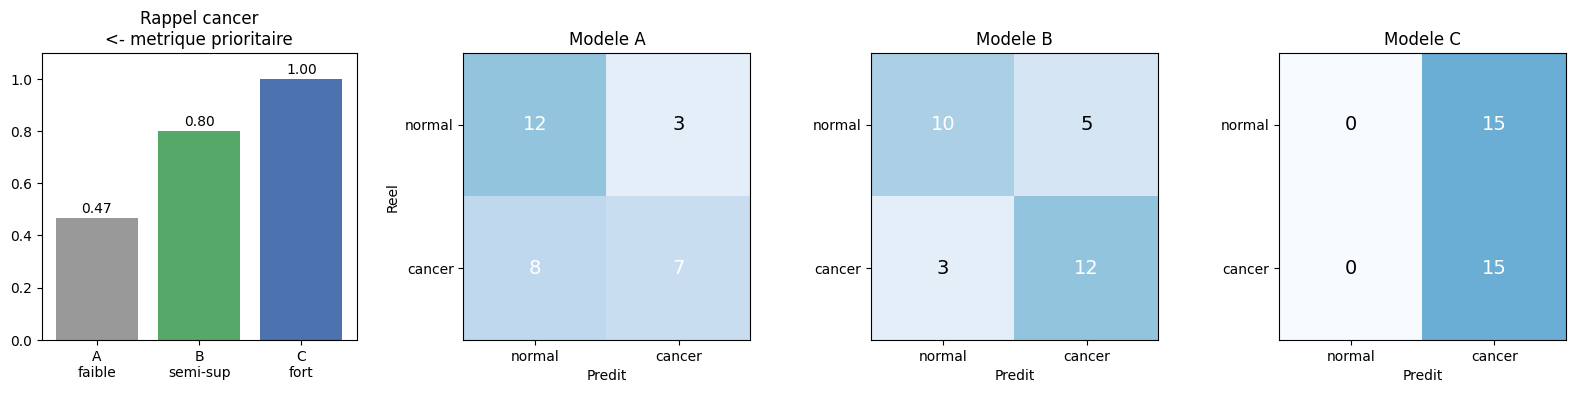

In [21]:
fig, axes = plt.subplots(1, 4, figsize=(16, 4))
recalls = [metrics_A["recall_cancer"], metrics_B["recall_cancer"], metrics_C["recall_cancer"]]
bars = axes[0].bar(["A\nfaible","B\nsemi-sup","C\nfort"], recalls, color=["#999","#55A868","#4C72B0"])
axes[0].set_ylim(0,1.1); axes[0].set_title("Rappel cancer\n<- metrique prioritaire")
for b, v in zip(bars, recalls):
    axes[0].text(b.get_x()+b.get_width()/2, v+0.02, f"{v:.2f}", ha="center")

for idx, (name, m) in enumerate([("A",metrics_A),("B",metrics_B),("C",metrics_C)]):
    ax = axes[idx+1]; cm = m["confusion"]
    ax.imshow(cm, cmap="Blues", vmin=0, vmax=test_strong.shape[0])
    for i in range(2):
        for j in range(2):
            ax.text(j,i,str(cm[i,j]),ha="center",va="center",
                    color="white" if cm[i,j]>cm.max()/2 else "black", fontsize=14)
    ax.set_xticks([0,1]); ax.set_xticklabels(["normal","cancer"])
    ax.set_yticks([0,1]); ax.set_yticklabels(["normal","cancer"])
    ax.set_xlabel("Predit"); ax.set_ylabel("Reel" if idx==0 else ""); ax.set_title(f"Modele {name}")

plt.tight_layout(); plt.savefig("resultats_comparaison.png", dpi=130, bbox_inches="tight"); plt.show()

In [22]:
model_B.eval()
loader_u = DataLoader(ImgDatasetGray(df_weak["filepath"]), batch_size=32, shuffle=False)
preds_u, confs_u = [], []
with torch.no_grad():
    for xb in loader_u:
        out = model_B(xb.repeat(1,3,1,1).to(DEVICE))
        probs = torch.softmax(out, dim=1)
        preds_u.extend(out.argmax(1).cpu().numpy().tolist())
        confs_u.extend(probs.max(1).values.cpu().numpy().tolist())

df_weak["label_predit"] = [IDX2LABEL[p] for p in preds_u]
df_weak["confiance"]    = confs_u
print("Repartition predictions sur sans_label :")
print(df_weak["label_predit"].value_counts())
print(f"Confiance moyenne : {np.mean(confs_u):.3f}")
print(f"Images a faible confiance (<0.70) : {sum(c<0.70 for c in confs_u)}")
df_weak.to_csv("predictions_sans_label.csv", index=False)
print("Sauvegarde -> predictions_sans_label.csv")

Repartition predictions sur sans_label :
label_predit
cancer    1027
normal     347
Name: count, dtype: int64
Confiance moyenne : 0.680
Images a faible confiance (<0.70) : 883
Sauvegarde -> predictions_sans_label.csv


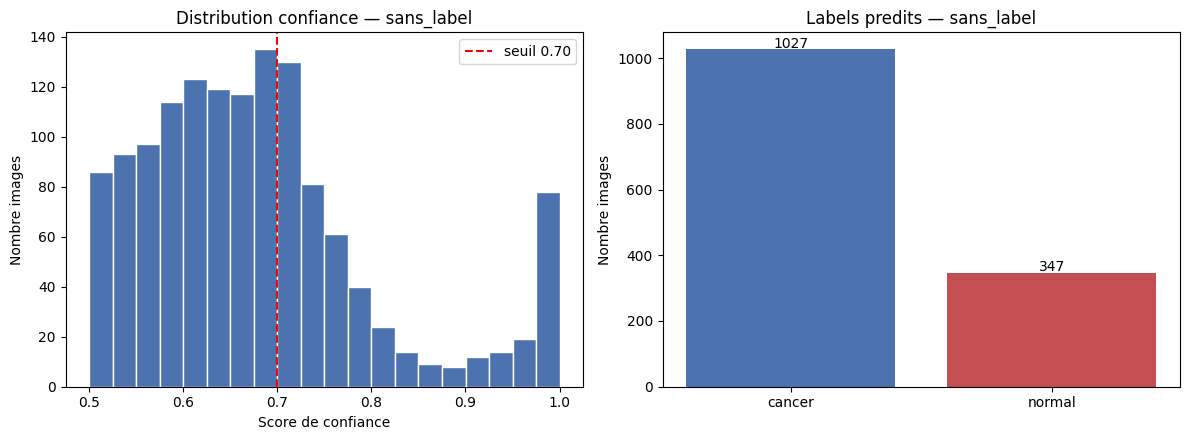

In [23]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))
axes[0].hist(confs_u, bins=20, color="#4C72B0", edgecolor="white")
axes[0].axvline(0.70, color="red", linestyle="--", label="seuil 0.70")
axes[0].set_xlabel("Score de confiance"); axes[0].set_ylabel("Nombre images")
axes[0].set_title("Distribution confiance — sans_label"); axes[0].legend()

counts = df_weak["label_predit"].value_counts()
bars = axes[1].bar(counts.index, counts.values, color=["#4C72B0","#C44E52"])
for b, v in zip(bars, counts.values):
    axes[1].text(b.get_x()+b.get_width()/2, v+5, str(v), ha="center")
axes[1].set_ylabel("Nombre images"); axes[1].set_title("Labels predits — sans_label")
plt.tight_layout(); plt.savefig("predictions_distribution.png", dpi=130, bbox_inches="tight"); plt.show()

## Conclusion

| | Auto-encodeur | ResNet18 ImageNet | **RadImageNet** |
|--|--|--|--|
| Pré-entraînement | Nos données (1374 imgs) | 1.3M photos naturelles | **1.35M images médicales** |
| Dimension embeddings | 64 | 512 | **2048** |
| Pertinence médicale | Faible | Moyenne | **Élevée** |

RadImageNet est le choix le plus pertinent pour ce projet — ses features ont été apprises sur des IRM, scanners et échographies, ce qui est directement adapté à notre tâche.

**Limite principale** : 30 images de test seulement — les métriques sont indicatives. Un jeu de test indépendant validé médicalement est nécessaire avant tout usage clinique.